**------------------------ Libraries**

In [2]:
# !pip install scorecardpy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scorecardpy as sc
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import joblib
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings

**------------------------ Loading data**

In [4]:
# Load column names from the file
warnings.filterwarnings('ignore')
with open('census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f.readlines()]

columns

['age',
 'class of worker',
 'detailed industry recode',
 'detailed occupation recode',
 'education',
 'wage per hour',
 'enroll in edu inst last wk',
 'marital stat',
 'major industry code',
 'major occupation code',
 'race',
 'hispanic origin',
 'sex',
 'member of a labor union',
 'reason for unemployment',
 'full or part time employment stat',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'tax filer stat',
 'region of previous residence',
 'state of previous residence',
 'detailed household and family stat',
 'detailed household summary in household',
 'weight',
 'migration code-change in msa',
 'migration code-change in reg',
 'migration code-move within reg',
 'live in this house 1 year ago',
 'migration prev res in sunbelt',
 'num persons worked for employer',
 'family members under 18',
 'country of birth father',
 'country of birth mother',
 'country of birth self',
 'citizenship',
 'own business or self employed',
 "fill inc questionnaire for veteran's admin"

In [5]:
# Load the dataset
df = pd.read_csv('census-bureau.data', header=None, names=columns,
                 na_values='?', skipinitialspace=True)

# Show all of the columns when df is printed
pd.set_option('display.max_columns', None)

print(f'Dataset shape (rows, columns) = {df.shape}.')
df.head(4)

Dataset shape (rows, columns) = (199523, 42).


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


**------------------------ Let's take a look at Data type, missing values, non-null% and unique values of each variable/feature**

In [6]:
# Combine all explorations into one summary table
summary = pd.concat([
    df.dtypes.to_frame(name='Data Type'),
    df.isna().sum().to_frame(name='Null Counts'),
    (df.notnull().mean() * 100).to_frame(name='Non-Null %'),
    df.nunique().to_frame(name='Unique Values')
], axis=1)

summary

,Data Type,Null Counts,Non-Null %,Unique Values
age,int64,0,100.000000,91
class of worker,object,0,100.000000,9
detailed industry recode,int64,0,100.000000,52
detailed occupation recode,int64,0,100.000000,47
education,object,0,100.000000,17
wage per hour,int64,0,100.000000,1240
enroll in edu inst last wk,object,0,100.000000,3
marital stat,object,0,100.000000,7
major industry code,object,0,100.000000,24
major occupation code,object,0,100.000000,15


**------------------------ Let's take a look at the weight column**

In [7]:
# The sum of the weight column values should represent the US population at the time of record
df['weight'].sum()

np.float64(347245892.46999997)

The sum of the weight column values should represent the US population at the time of record

**------------------------ Dropping duplicate rows**

In [8]:
# Dataset shape size before dropping duplicates
print(f'Dataset shape "before" dropping duplicates (rows, columns) = {df.shape}.')

df.drop_duplicates(inplace=True)

print(f'Dataset shape "after" dropping duplicates (rows, columns) = {df.shape}.')

Dataset shape "before" dropping duplicates (rows, columns) = (199523, 42).
Dataset shape "after" dropping duplicates (rows, columns) = (196294, 42).


3229 rows that were duplicates were dropped. In our case it is 1.6% of the whole dataset. So we can go further as the dataset has barely changed in numbers. However, in cases when the number drops significantly further exploration is needed within the dataset.

**------------------------ Target label**

In [9]:
# We convert labels into a binary format: 0 for <50k and 1 for >50k. This will be the target
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})
df.rename(columns={'label': 'target'}, inplace=True )
print(f'Dataset shape (rows, columns) = {df.shape}.')
df.head(4)

Dataset shape (rows, columns) = (196294, 42).


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,target
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,0


**------------------------ Handling Missing Values**

In [10]:
# Many columns have 'Not in universe' that we will use as a category
# Truly missing values (NaN) will be filled with 'Unknown'.
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
print(f'Dataset shape (rows, columns) = {df.shape}.')
df.head(4)

Dataset shape (rows, columns) = (196294, 42).


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,target
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,Unknown,Unknown,Unknown,Not in universe under 1 year old,Unknown,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,Unknown,Unknown,Unknown,Not in universe under 1 year old,Unknown,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,0


**------------------------ Income distribution**

Dataset shape (rows, columns) = (196294, 42).
Income distribution:
(Income more than 50k): 6.31%
(income less than 50k): 93.69%


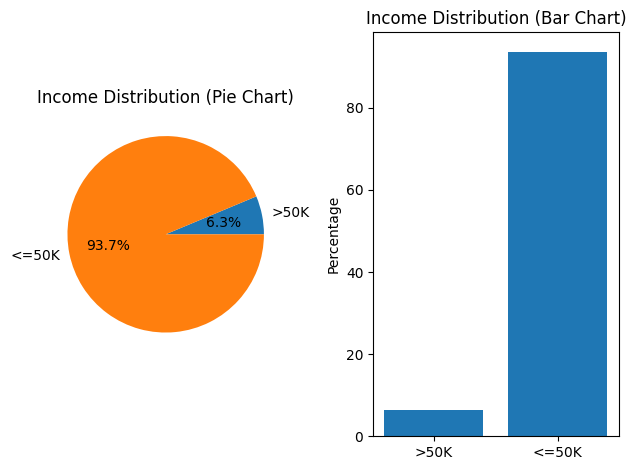

In [11]:
# What percentage has more than 50k income and vice versa
income_more50k = df['target'].sum() / len(df['target']) * 100
income_less50k = 100 - income_more50k

print(f'''Dataset shape (rows, columns) = {df.shape}.
Income distribution:\n(Income more than 50k): {income_more50k:.2f}%\n(income less than 50k): {income_less50k:.2f}%''')

labels = ['>50K', '<=50K']
values = [income_more50k, income_less50k]
fig, axes = plt.subplots(1, 2)

# Pie Chart
axes[0].pie(values, labels=labels, autopct='%1.1f%%')
axes[0].set_title('Income Distribution (Pie Chart)')

# Bar Chart
axes[1].bar(labels, values)
axes[1].set_ylabel('Percentage')
axes[1].set_title('Income Distribution (Bar Chart)')

###
plt.tight_layout()
plt.show()

We can see that the dataset is unbalanced with 93.69% having less than 50k and 6.31% more than 50k income. We should take it into account while training a model

**Age distribution by income levels**

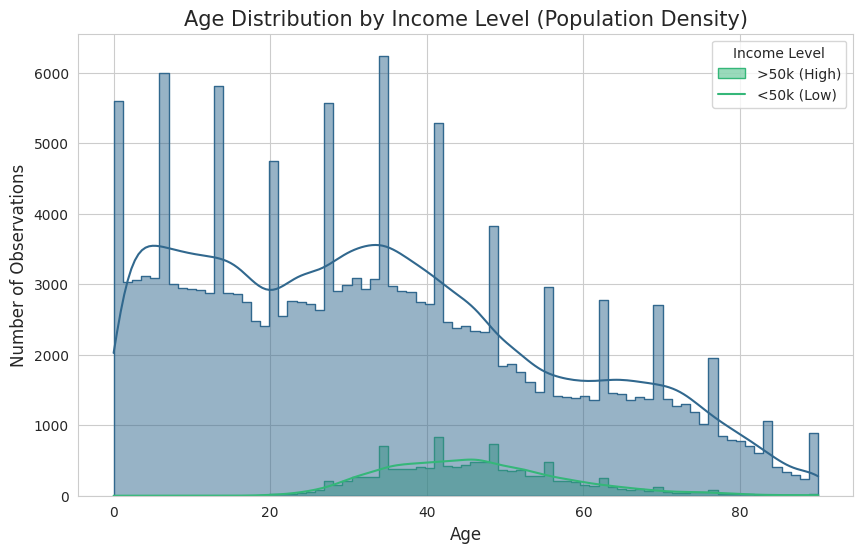

Average age for individuals earning <$50k: 34.2 years
Average age for individuals earning >$50k: 46.3 years


In [12]:
# Working on visualization
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='age', hue='target', kde=True, element="step", palette='viridis', alpha=0.5)

plt.title('Age Distribution by Income Level (Population Density)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)

# Customizing legend
plt.legend(title='Income Level', labels=['>50k (High)', '<50k (Low)'])

plt.show()

# Average age for each group
avg_age = df.groupby('target')['age'].mean()
print(f"Average age for individuals earning <$50k: {avg_age[0]:.1f} years")
print(f"Average age for individuals earning >$50k: {avg_age[1]:.1f} years")

**~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~**

**------------------------ Feature Selection ------------------------**

**While training a model or performing tasks we have to choose which features/columns to use from our dataset. Reasons: 1) Not all the features are informative enough to contribute to the model 2) It makes model more robust and it will become slow to train 3) Harder to interpret and explain to stakeholders 4) Harder to interprit for regulators.

Therefore, following is a set of algorithms that automatically selects the best features from the dataset to include in the model training. Each model selects a set of informative features and the final result will be their ensembe vote. This is the architecture and all the explanation and visualization will be provided in the report**

In [13]:
# We extract the weight column from the dataset
w = df['weight']

**------------------------ Information Value**

In [14]:
def calculate_information_value(df):
  """
  Calculates information value for each feature based on the Weight of Evidence (WOE).
  Works even with null values as the algorithm considers them as valuable info as well.

  Args:
    df (pd.DataFrame): Dataset with featuresa and target.
  Returns:
    iv_df (pd.DataFrame): Features and their corresponding Information Value.
  """


  # Calculate IV for features
  bins = sc.woebin(df, y='target')

  # Extract and display the IV values
  iv_values = {col: bins[col]['total_iv'].iloc[0] for col in bins.keys()}
  iv_df = pd.DataFrame(list(iv_values.items()), columns=["Feature", "IV"]).sort_values(by="IV", ascending=False)

  return iv_df

df_iv = calculate_information_value(df)

df_iv

[INFO] creating woe binning ...
>>> There are 1 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
state of previous residence
>>> Continue the binning process?
1: yes 
2: no
Selection: 1
Binning on 196294 rows and 42 columns in 00:00:32


,Feature,IV
27,education,3.134365
0,age,2.679329
30,detailed household and family stat,2.642950
29,detailed household summary in household,2.466898
8,tax filer stat,2.233788
38,family members under 18,2.210636
28,major occupation code,1.913196
25,detailed occupation recode,1.901229
2,weeks worked in year,1.620723
1,major industry code,1.418193


**------------------------ Significance Principal**

In [15]:
def calculate_significance_principal(df):
    # FIll null values with 0
    df.fillna(0, inplace=True)

    # If True/False convert into 1/0 in target
    X = df.drop('target', axis=1)
    X = X.select_dtypes(include=[np.number])  # Keep only numeric columns
    y = df['target'].astype(int)

    # Split the data into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, shuffle=True, stratify=y)

    # Normalizing data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with L1 regularization (Lasso)
    model_lr = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=1)
    model_lr.fit(X_train_scaled, y_train)

    # Feature selection using model coefficients
    model = SelectFromModel(model_lr, prefit=True)
    selected_features = X.columns[model.get_support()]

    # Print selected features
    print(f'Selected features: {selected_features.tolist()}')

    # Transform dataset with selected features
    X_train_selected = model.transform(X_train_scaled)
    X_test_selected = model.transform(X_test_scaled)

    # Train final logistic regression model
    final_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
    final_model.fit(X_train_selected, y_train)

    # Predictions
    y_pred = final_model.predict(X_test_selected)
    y_pred_proba = final_model.predict_proba(X_test_selected)[:, 1]  # Probabilities for positive class

    # Compute evaluation metrics
    accuracy = final_model.score(X_test_selected, y_test)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Print results
    print(f'Final model accuracy: {accuracy:.4f}')
    print(f'Final model F1-score: {f1:.4f}')
    print(f'Final model ROC AUC score: {roc_auc:.4f}')

    # Detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return selected_features.tolist()


signif_princ_features = calculate_significance_principal(df)

signif_princ_features

Selected features: ['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'weight', 'num persons worked for employer', 'own business or self employed', 'weeks worked in year', 'year']
Final model accuracy: 0.9456
Final model F1-score: 0.3288
Final model ROC AUC score: 0.9077

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     36783
           1       0.74      0.21      0.33      2476

    accuracy                           0.95     39259
   macro avg       0.85      0.60      0.65     39259
weighted avg       0.94      0.95      0.93     39259



['age',
 'detailed industry recode',
 'detailed occupation recode',
 'wage per hour',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'weight',
 'num persons worked for employer',
 'own business or self employed',
 'weeks worked in year',
 'year']

In [16]:
# Identify numerical and non-numerical features
num_features = df.select_dtypes(include=['number']).columns.tolist()
num_features = [col for col in num_features if col != 'target']

cat_features = [col for col in df.columns if col not in num_features + ['target']]

# IV-selected features
df_iv_best_features = df_iv[df_iv['IV'] > 1]['Feature'].tolist()

# Split IV features into numerical and categorical
iv_num_features = [f for f in df_iv_best_features if f in num_features]
iv_cat_features = [f for f in df_iv_best_features if f in cat_features]

# Ensemble vote ONLY on numerical features
ensemble_num_features = list(set(iv_num_features) & set(signif_princ_features))

# Final features
final_features = ensemble_num_features + iv_cat_features + ['target']

df = df[final_features]

final_features

['age',
 'weeks worked in year',
 'detailed industry recode',
 'detailed occupation recode',
 'num persons worked for employer',
 'education',
 'detailed household and family stat',
 'detailed household summary in household',
 'tax filer stat',
 'family members under 18',
 'major occupation code',
 'major industry code',
 'class of worker',
 'target']

**Numner of removed features**

In [17]:
42 - len(final_features)

28

**------------------------ Varice Inflation Factore (VIF)**

In [18]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, target_column):
    """
    Calculates Variance Inflation Factor (VIF) that shows the correlation between features.
    High VIF indicates that the corresponding feature can be calculated from other features,
    hence can be dropped.

    Args:
      df (pd.DataFrame): Dataset with features and target.
      target_column (str): Name of the target column.
    Returns:
      vif_data (pd.DataFrame): Features and their corresponding VIF values.
    """

    # Remove the target column from the dataframe
    df = df.drop(columns=[target_column])

    # Ensure all variables are numeric
    df = df.select_dtypes(include=[np.number])

    # Fill null values with zero
    df.fillna(0, inplace=True)

    # Add a constant term to the dataframe for the intercept
    df = sm.add_constant(df)

    # Create a dataframe to hold VIF values
    vif_data = pd.DataFrame()
    vif_data['feature'] = df.columns

    # Calculate VIF for each feature
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

    return vif_data


vif_df = calculate_vif(df, 'target')

# Sort the VIF DataFrame in descending order based on VIF values
vif_df_sorted = vif_df.sort_values(by='VIF', ascending=False)

# Round the VIF values to two decimal places and format them without scientific notation
vif_df_sorted['VIF'] = vif_df_sorted['VIF'].apply(lambda x: '{:.2f}'.format(x))

vif_df_sorted

,feature,VIF
0,const,4.06
2,weeks worked in year,3.68
3,detailed industry recode,2.41
5,num persons worked for employer,2.32
4,detailed occupation recode,1.77
1,age,1.04


| VIF value  | Interpretation                                               |
| ---------- | ------------------------------------------------------------ |
| **≈ 1**    | No correlation with other features (ideal)                   |
| **1 – 5**  | Moderate correlation (usually fine)                          |
| **5 – 10** | High correlation (warning zone)                              |
| **> 10**   | Very high multicollinearity (problematic, consider dropping) |

**------------------------ Stepwise Selection**

In [19]:
def stepwise_selection(df, target_column='target', scoring_metric='roc_auc', cv_folds=5):
  """
  Performs recursive feature elimination with cros-validation (RFECV) to select the best features.

  Args:
    df (pd.DataFrame): Dataset containing feature and target.
    target_column (str): Name of the target column in the dataset.
    scoring_metric (str): Scoring metric for feature selection.
    cv_folds (int): Number of cross-validation folds.

  Returns:
    selected_features (list): List of selected feature names.
    df_selected (pd.DataFrame): DataFrame containing only the selected features and target.
    feature_ranking (dict): Dictionary mapping features to their ranking.
  """

  # Replace null values with 0
  df.fillna(0, inplace=True)

  # Separate predictors and target variable
  X = df.drop(columns=[target_column])
  X = X.select_dtypes(include=[np.number])
  y = df[target_column].astype(int) # Convert True/False target into 1/0

  # Initialize LR model
  model = LogisticRegression(solver='liblinear')

  # Perform RFECV with stratified cross-validation
  cv = StratifiedKFold(n_splits=cv_folds)
  rfecv = RFECV(estimator=model, step=1, cv=cv, scoring=scoring_metric)
  rfecv.fit(X, y)

  # Obtain selected features.
  selected_features = X.columns[rfecv.support_]
  feature_rankings = dict(zip(X.columns, rfecv.ranking_))

  print(f'Optimal number of features: {rfecv.n_features_}')
  print(f'Selected features: {list(selected_features)}')

  # Create a reduced DataFrame with selected features
  df_selected = df[selected_features].copy()
  df_selected[target_column] = y # add back target column

  return list(selected_features), df_selected, feature_rankings


selected_features, df_selected, feature_rankings = stepwise_selection(df)

Optimal number of features: 5
Selected features: ['age', 'weeks worked in year', 'detailed industry recode', 'detailed occupation recode', 'num persons worked for employer']


In [20]:
selected_features

['age',
 'weeks worked in year',
 'detailed industry recode',
 'detailed occupation recode',
 'num persons worked for employer']

**------------------------ Final selected most informative features to predict the target**

In [21]:
# numeric columns in original df
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()

# keep only valid selected numeric features (just in case)
selected_numeric_features = [f for f in selected_features if f in numeric_cols]

# final dataframe
df = df[selected_numeric_features + non_numeric_cols + ['target']]

print(f'Dataset shape (rows, columns) = {df.shape}.')
df.head(4)

Dataset shape (rows, columns) = (196294, 14).


,age,weeks worked in year,detailed industry recode,detailed occupation recode,num persons worked for employer,education,detailed household and family stat,detailed household summary in household,tax filer stat,family members under 18,major occupation code,major industry code,class of worker,target
0,73,0,0,0,0,High school graduate,Other Rel 18+ ever marr not in subfamily,Other relative of householder,Nonfiler,Not in universe,Not in universe,Not in universe or children,Not in universe,0
1,58,52,4,34,1,Some college but no degree,Householder,Householder,Head of household,Not in universe,Precision production craft & repair,Construction,Self-employed-not incorporated,0
2,18,0,0,0,0,10th grade,Child 18+ never marr Not in a subfamily,Child 18 or older,Nonfiler,Not in universe,Not in universe,Not in universe or children,Not in universe,0
3,9,0,0,0,0,Children,Child <18 never marr not in subfamily,Child under 18 never married,Nonfiler,Both parents present,Not in universe,Not in universe or children,Not in universe,0


**~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~**

**------------------------ Training a classifier ------------------------**

**Logistic Regresssiion**

Automatically identified 5 numeric and 8 categorical features.
Best Hyperparameters: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Logistic Regression Results:
Accuracy: 0.8260     F1-Score:0.3914     ROC-AUC:0.9312     Gini:0.8624



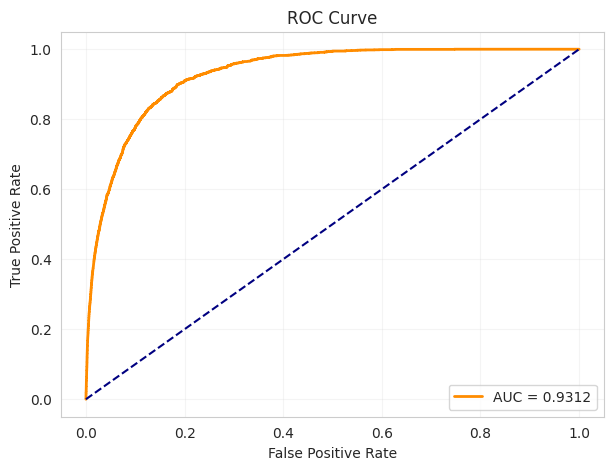

In [22]:
# Automatic Feature Detection & Splitting
target = 'target'
X = df.drop(columns=[target])
y = df[target]

# Automatically detect types
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, stratify=y, random_state=1
)

# Pipeline Definition
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=1, max_iter=500))
])

# Grid Search & Training
param_grid = {
    'classifier__C': [0.01, 0.1, 0.5, 1, 5, 10],
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l2'],
    'classifier__class_weight': ['balanced']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fitting data
grid_search.fit(X_train, y_train, classifier__sample_weight=w_train)

best_model = grid_search.best_estimator_

# Evaluation
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc, gini = auc(fpr, tpr), (2 * auc(fpr, tpr) - 1)

print(f"Automatically identified {len(numeric_features)} numeric and {len(categorical_features)} categorical features.")
print(f"Best Hyperparameters: {grid_search.best_params_}\n")
print(f"Logistic Regression Results:")
print(f'''Accuracy: {accuracy_score(y_test, y_pred):.4f}     F1-Score:{f1_score(y_test, y_pred):.4f}     ROC-AUC:{roc_auc:.4f}     Gini:{gini:.4f}\n''')

# Plotting ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.show()

In [23]:
# Feature Importance
# Extract feature names
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features_transformed = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features_transformed)

# Mapping Coefficients
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Weight': best_model.named_steps['classifier'].coef_[0]
}).sort_values(by='Weight', ascending=False)

print("\nTop 5 High-Income Predictors:")
print(importance_df.head(5))
print("\nTop 5 low-Income Predictors:")
print(importance_df.tail(5))

X_transformed = best_model.named_steps['preprocessor'].transform(X_train)
df_transformed = pd.DataFrame(
    X_transformed.toarray() if hasattr(X_transformed, 'toarray') else X_transformed,
    columns=all_feature_names
)

display(df_transformed.head(4))


Top 5 High-Income Predictors:
                                               Feature    Weight
16                 education_Doctorate degree(PhD EdD)  3.047709
20    education_Prof school degree (MD DDS DVM LLB JD)  2.887911
19    education_Masters degree(MA MS MEng MEd MSW MBA)  2.105467
81   major occupation code_Farming forestry and fis...  2.081786
106                         major industry code_Mining  2.027000

Top 5 low-Income Predictors:
                                               Feature    Weight
125                        class of worker_Without pay -2.375493
47   detailed household and family stat_Other Rel 1... -2.392647
80   major occupation code_Executive admin and mana... -2.628663
15                                  education_Children -3.688531
18                       education_Less than 1st grade -5.152735


,age,weeks worked in year,detailed industry recode,detailed occupation recode,num persons worked for employer,education_10th grade,education_11th grade,education_12th grade no diploma,education_1st 2nd 3rd or 4th grade,education_5th or 6th grade,education_7th and 8th grade,education_9th grade,education_Associates degree-academic program,education_Associates degree-occup /vocational,education_Bachelors degree(BA AB BS),education_Children,education_Doctorate degree(PhD EdD),education_High school graduate,education_Less than 1st grade,education_Masters degree(MA MS MEng MEd MSW MBA),education_Prof school degree (MD DDS DVM LLB JD),education_Some college but no degree,detailed household and family stat_Child 18+ ever marr Not in a subfamily,detailed household and family stat_Child 18+ ever marr RP of subfamily,detailed household and family stat_Child 18+ never marr Not in a subfamily,detailed household and family stat_Child 18+ never marr RP of subfamily,detailed household and family stat_Child 18+ spouse of subfamily RP,detailed household and family stat_Child <18 ever marr RP of subfamily,detailed household and family stat_Child <18 ever marr not in subfamily,detailed household and family stat_Child <18 never marr RP of subfamily,detailed household and family stat_Child <18 never marr not in subfamily,detailed household and family stat_Child <18 spouse of subfamily RP,detailed household and family stat_Child under 18 of RP of unrel subfamily,detailed household and family stat_Grandchild 18+ ever marr RP of subfamily,detailed household and family stat_Grandchild 18+ ever marr not in subfamily,detailed household and family stat_Grandchild 18+ never marr RP of subfamily,detailed household and family stat_Grandchild 18+ never marr not in subfamily,detailed household and family stat_Grandchild 18+ spouse of subfamily RP,detailed household and family stat_Grandchild <18 ever marr not in subfamily,detailed household and family stat_Grandchild <18 never marr RP of subfamily,detailed household and family stat_Grandchild <18 never marr child of subfamily RP,detailed household and family stat_Grandchild <18 never marr not in subfamily,detailed household and family stat_Householder,detailed household and family stat_In group quarters,detailed household and family stat_Nonfamily householder,detailed household and family stat_Other Rel 18+ ever marr RP of subfamily,detailed household and family stat_Other Rel 18+ ever marr not in subfamily,detailed household and family stat_Other Rel 18+ never marr RP of subfamily,detailed household and family stat_Other Rel 18+ never marr not in subfamily,detailed household and family stat_Other Rel 18+ spouse of subfamily RP,detailed household and family stat_Other Rel <18 ever marr RP of subfamily,detailed household and family stat_Other Rel <18 never marr child of subfamily RP,detailed household and family stat_Other Rel <18 never marr not in subfamily,detailed household and family stat_Other Rel <18 never married RP of subfamily,detailed household and family stat_Other Rel <18 spouse of subfamily RP,detailed household and family stat_RP of unrelated subfamily,detailed household and family stat_Secondary individual,detailed household and family stat_Spouse of RP of unrelated subfamily,detailed household and family stat_Spouse of householder,detailed household summary in household_Child 18 or older,detailed household summary in household_Child under 18 ever married,detailed household summary in household_Child under 18 never married,detailed household summary in household_Group Quarters- Secondary individual,detailed household summary in household_Householder,detailed household summary in household_Nonrelative of householder,detailed household summary in household_Other relative of householder,detailed household summary in household_Spouse of householder,tax filer stat_Head of household,tax filer stat_Joint both 65+,tax filer stat_Joint both under 65,tax filer stat_Joint one under 65 & one 65+,tax filer st

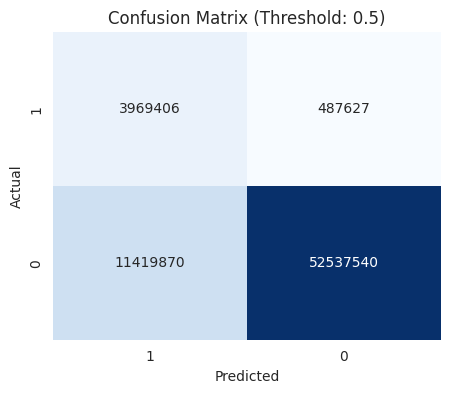

Model saved as logistic_regression.pkl


In [24]:
def plot_tuned_confusion_matrix(model, X_test, y_test, threshold=0.5):
    # Get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Apply custom threshold
    y_pred_tuned = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_tuned, labels=[1, 0], sample_weight=w_test)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', cbar=False,
                xticklabels=[1, 0], yticklabels=[1, 0])

    plt.title(f'Confusion Matrix (Threshold: {threshold})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


plot_tuned_confusion_matrix(best_model, X_test, y_test, threshold=0.5)

# Save Model
joblib.dump(best_model, 'logistic_regression.pkl')
print("Model saved as logistic_regression.pkl")

****
**~~~~~~~~~~~~~~~~~~~~~~~~~ Different algorithms for demonstration (Will be explained in the report why included here)**

In [25]:
# Dictionary to store results for final comparison
comparison_metrics = {}

def get_metrics(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    gini = 2 * roc_auc - 1

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc,
        'Gini': gini
    }
    comparison_metrics[name] = metrics
    return metrics


# --- SVM ---
# svm_pipe = Pipeline(steps=[('preprocessor', preprocessor),
#                             ('classifier', SVC(probability=True, kernel='linear', class_weight='balanced'))])
# svm_pipe.fit(X_train, y_train)
# get_metrics(svm_pipe, X_test, y_test, "SVM")

# --- Random Forest ---
rf_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(class_weight='balanced'))])
rf_pipe.fit(X_train, y_train, classifier__sample_weight=w_train)
res_rf = get_metrics(rf_pipe, X_test, y_test, "Random Forest")

# --- XGBoost ---
xgb_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', XGBClassifier(eval_metric='logloss'))])
xgb_pipe.fit(X_train, y_train, classifier__sample_weight=w_train)
get_metrics(xgb_pipe, X_test, y_test, "XGBoost")

comparison_metrics

{'Random Forest': {'Accuracy': 0.9364476935225043,
  'F1-Score': 0.42997486863148277,
  'ROC-AUC': np.float64(0.8897324655710124),
  'Gini': np.float64(0.7794649311420248)},
 'XGBoost': {'Accuracy': 0.9465345525866681,
  'F1-Score': 0.47141777889700326,
  'ROC-AUC': np.float64(0.9305929698945616),
  'Gini': np.float64(0.8611859397891233)}}

**Neural Networks with PyTorch**

In [26]:
# Transforming features
X_train_transformed = preprocessor.fit_transform(X_train).toarray()
X_test_transformed = preprocessor.transform(X_test).toarray()

class WeightedScoringDataset(Dataset):
    def __init__(self, x, y, w):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
        self.w = torch.tensor(w.values, dtype=torch.float32) # Census weights

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.w[idx]

# Creating DataLoaders with weights aligned to features and targets
train_loader = DataLoader(WeightedScoringDataset(X_train_transformed, y_train, w_train), batch_size=256, shuffle=True)
test_loader = DataLoader(WeightedScoringDataset(X_test_transformed, y_test, w_test), batch_size=64)

# Model
class CreditClassifier(nn.Module):
    def __init__(self, input_dim):
        super(CreditClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

# Initialize Model, Optimizer, and Loss Function
input_dim = X_train_transformed.shape[1]
model_nn = CreditClassifier(input_dim)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

# Reduction='none' allows us to multiply each loss by its specific census weight
criterion = nn.CrossEntropyLoss(reduction='none')

# Training Loop
print("Training Weighted Neural Network...")
model_nn.train()
for epoch in range(21):
    epoch_loss = 0
    for batch_x, batch_y, batch_w in train_loader:
        optimizer.zero_grad()
        outputs = model_nn(batch_x)

        # Calculate raw loss then apply census weights manually
        raw_loss = criterion(outputs, batch_y)
        weighted_loss = (raw_loss * batch_w).mean()

        weighted_loss.backward()
        optimizer.step()
        epoch_loss += weighted_loss.item()

    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Weighted Loss: {epoch_loss/len(train_loader):.4f}")

# Evaluation (Weighted Metrics)
model_nn.eval()
all_probs, all_preds = [], []

with torch.no_grad():
    for batch_x, _, _ in test_loader:
        logits = model_nn(batch_x)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())

# Metrics
nn_fpr, nn_tpr, _ = roc_curve(y_test, all_probs, sample_weight=w_test)
nn_auc = auc(nn_fpr, nn_tpr)

print(f"\nWeighted Neural Network Results")
print(f"Accuracy (Weighted): {accuracy_score(y_test, all_preds, sample_weight=w_test):.4f}")
print(f"F1-Score (Weighted): {f1_score(y_test, all_preds, sample_weight=w_test):.4f}")
print(f"ROC-AUC (Weighted):  {nn_auc:.4f}")
print(f"Gini (Weighted):     {2 * nn_auc - 1:.4f}")

Training Weighted Neural Network...
Epoch 0 | Weighted Loss: 280.8385
Epoch 5 | Weighted Loss: 241.3190
Epoch 10 | Weighted Loss: 237.0389
Epoch 15 | Weighted Loss: 233.4728
Epoch 20 | Weighted Loss: 230.4359

Weighted Neural Network Results
Accuracy (Weighted): 0.9479
F1-Score (Weighted): 0.4751
ROC-AUC (Weighted):  0.9352
Gini (Weighted):     0.8703


****

**-------------------- Part 2: Segmentation**

In [27]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import seaborn as sns

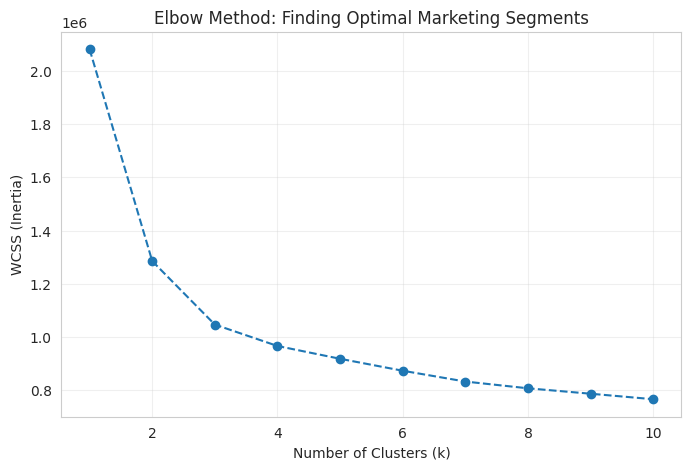

In [28]:
# Data preparation
X_transformed = preprocessor.transform(X).toarray()

# Run the Elbow Method
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=1, n_init=10)
    kmeans.fit(X_transformed)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method: Finding Optimal Marketing Segments')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(alpha=0.3)
plt.show()

Starting Dimensionality Reduction on a sample of 10000 rows...


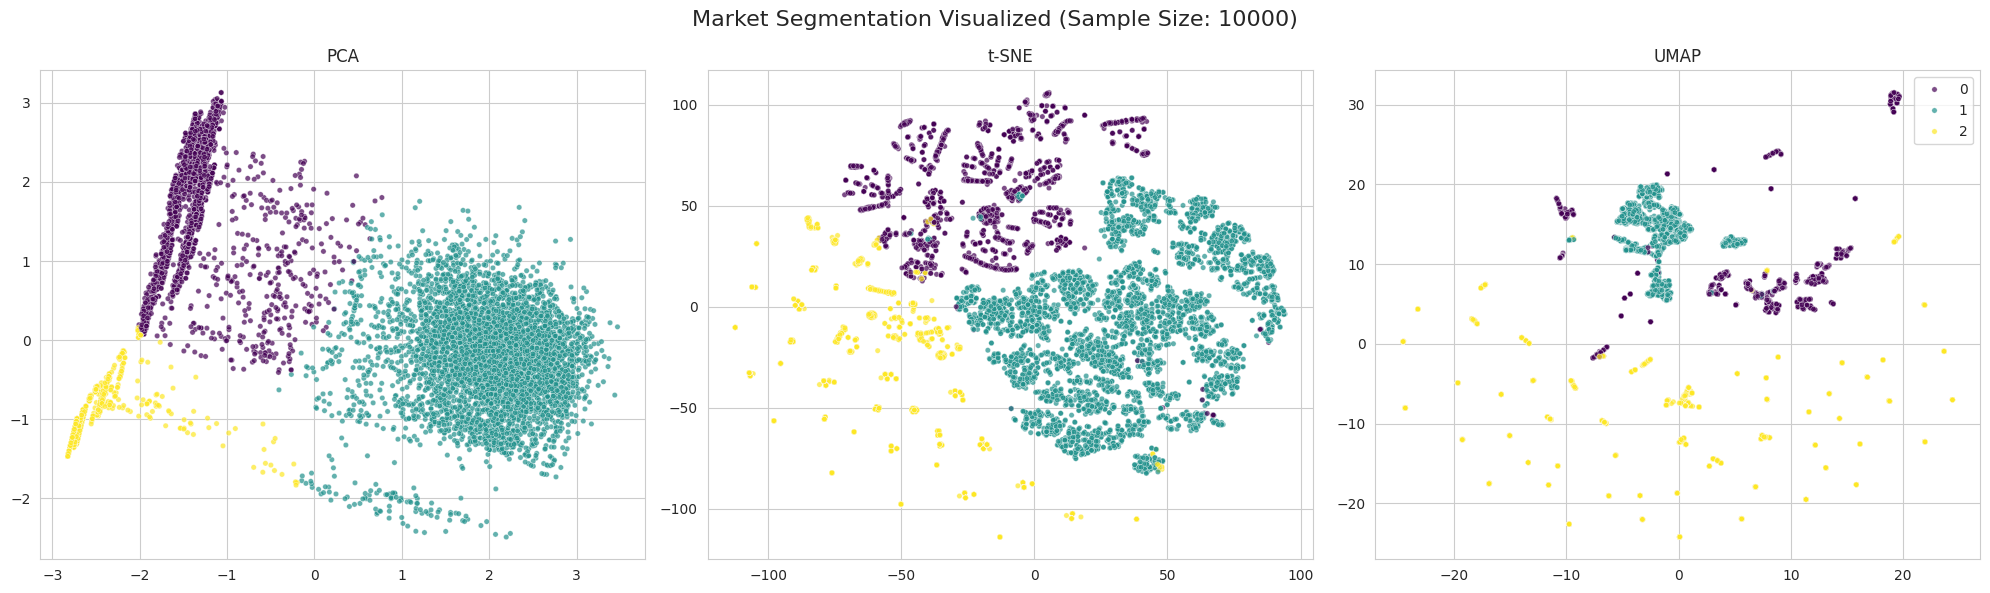

In [29]:
# Kmeans
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=1, n_init=10)
clusters = kmeans.fit_predict(X_transformed)
df['Segment'] = clusters

# We sample t-SNE and UMAP to speed them up.
viz_sample_size = min(10000, X_transformed.shape[0])
indices = np.random.choice(X_transformed.shape[0], viz_sample_size, replace=False)

X_viz_sample = X_transformed[indices]
clusters_sample = clusters[indices]

print(f"Starting Dimensionality Reduction on a sample of {viz_sample_size} rows...")

# Dimensionality Reduction needed for visualization
pca_2d = PCA(n_components=2).fit_transform(X_viz_sample)
tsne_2d = TSNE(n_components=2, random_state=1, n_jobs=-1).fit_transform(X_viz_sample)
umap_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=1).fit_transform(X_viz_sample)

# Visual Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['PCA', 't-SNE', 'UMAP']
data_views = [pca_2d, tsne_2d, umap_2d]

for i, view in enumerate(data_views):
    sns.scatterplot(x=view[:, 0], y=view[:, 1], hue=clusters_sample, palette='viridis',
                    ax=axes[i], s=15, alpha=0.7, legend='full' if i==2 else None)
    axes[i].set_title(titles[i])

plt.suptitle(f'Market Segmentation Visualized (Sample Size: {viz_sample_size})', fontsize=16)
plt.tight_layout()
plt.show()

In [38]:
if 'weight' not in df.columns:
    df['weight'] = w

# Create a comprehensive profile of your 5 segments
segment_analysis = df.groupby('Segment').agg({
    'target': 'mean',                        # Income Probability (>50k)
    'age': 'mean',                           # Average Age
    'weeks worked in year': 'mean',          # Work Intensity
    'education': lambda x: x.mode()[0],      # Most common Education
    'major occupation code': lambda x: x.mode()[0], # Most common Job Type
    'tax filer stat': lambda x: x.mode()[0], # Family/Marital proxy
    'weight': 'sum'                          # Total Population represented
}).rename(columns={'weight': 'Population_Size', 'target': 'High_Earner_Ratio'})

# Calculate Population Percentage for the report
total_pop = segment_analysis['Population_Size'].sum()
segment_analysis['Pop_Percentage'] = (segment_analysis['Population_Size'] / total_pop) * 100

# Sorting so the client sees the most profitable groups first
segment_analysis = segment_analysis.sort_values(by='High_Earner_Ratio', ascending=False)

print(f"Market Segment Profiles")
display(segment_analysis)

Market Segment Profiles


,High_Earner_Ratio,age,weeks worked in year,education,major occupation code,tax filer stat,Population_Size,Pop_Percentage
Segment,,,,,,,,
1,0.116401,38.558105,45.106230,High school graduate,Adm support including clerical,Joint both under 65,1.756624e+08,51.334306
0,0.018771,56.701378,3.212632,High school graduate,Not in universe,Nonfiler,8.052383e+07,23.531703
2,0.000000,8.175631,0.262047,Children,Not in universe,Nonfiler,8.600675e+07,25.133991
